In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import pandas as pd

import json

SMALL_SIZE = 18
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizesa
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=15)    # legend fontsize
plt.rc('figure', titlesize=35)  # fontsize of the figure title

plt.rcParams.update({
"text.usetex": True,
"font.family": "serif",
"text.latex.preamble": r"\usepackage{amsmath}"
})

In [3]:
# Hyperparameters
gamma = 0.99
gamma_list = np.cumprod(np.repeat(gamma, 20))

In [4]:
def calc_cost(dir):
    with open(dir, 'r') as f:
        sim = json.load(f)

    cost_list = []
    cost_list_total = []
    num_sites = len(sim['hist_cost'])
    
    for j in range(num_sites): # Site
        total_cost = 0
        total_time = 0
        for time, cost in sim['hist_cost'][j]:
            # print(cost, cost * (gamma ** total_time), total_time)
            if time == 59 or time == 1:
                continue
            total_cost += cost * (gamma ** total_time)
            total_time += time

        total_cost /= ((1-gamma**(total_time+1))/(1-gamma))
        cost_list.append(-total_cost)
        
    cost_list = np.array(cost_list)
        
    return cost_list

In [5]:
collab_file_name = "experiment_results/100_1_8_0_nasa1_collaborative_2025-03-12-02-13-57/result.json"
iso_file_name = "experiment_results/100_1_8_0_nasa1_isolated_2025-03-12-03-38-23/result.json"
ep_file_name = "experiment_results/100_1_8_0_nasa1_EP_2025-03-12-12-35-26/result.json"
collab_lap_1_file_name = "experiment_results/100_1_8_1.0_nasa1_collaborative_2025-03-11-21-33-34/result.json"
collab_lap_2_file_name = "experiment_results/100_1_8_3.0_nasa1_collaborative_2025-03-11-23-54-12/result.json"

collab_cost = calc_cost(collab_file_name)
iso_cost = calc_cost(iso_file_name)
ep_cost = calc_cost(ep_file_name)
collab_1_cost = calc_cost(collab_lap_1_file_name)
collab_2_cost = calc_cost(collab_lap_2_file_name)

In [6]:
sim_accu = [collab_cost[collab_cost < 4], collab_2_cost[collab_2_cost < 4]
            , ep_cost[ep_cost < 4], iso_cost[iso_cost < 4]]
# sim_accu = [collab_cost, collab_1_cost, ep_cost, iso_cost]
# sim_accu_total = [collab_cost_total, collab_1_cost_total, collab_2_cost_total, ep_cost_total, iso_cost_total]
df_data = pd.DataFrame(columns=['collab', 'collab_1', 'collab_2' 'EP', 'isolated'])
df_data['collab'] = collab_cost
df_data['collab_1'] = collab_1_cost
df_data['collab_2'] = collab_2_cost
df_data['isolated'] = iso_cost
df_data['EP'] = ep_cost

In [7]:
with open(collab_file_name, 'r') as f:
    s_collab = json.load(f)
    
with open(ep_file_name, 'r') as f:
    s_ep = json.load(f)

for i in range(len(s_collab['hist_cost'])):
    print(s_collab['hist_cost'][i])
    print(s_ep['hist_cost'][i])
    print('-'*20)

[[59, -5.027634173858118]]
[[59, -5.027634173858118]]
--------------------
[[30, -5.036985018669412]]
[[22, -5.040081529476952]]
--------------------
[[7, -5.046603267395349]]
[[7, -5.046603267395349]]
--------------------
[[10, -5.04521910375044]]
[[10, -5.04521910375044]]
--------------------
[[6, -5.04707400747005]]
[[6, -5.04707400747005]]
--------------------
[[7, -5.046603267395349]]
[[7, -5.046603267395349]]
--------------------
[[59, -5.027634173858118]]
[[59, -5.027634173858118]]
--------------------
[[19, -5.041308431191778]]
[[10, -5.04521910375044]]
--------------------
[[12, -5.044319243585807]]
[[12, -5.044319243585807]]
--------------------
[[8, -5.046137234721396]]
[[8, -5.046137234721396]]
--------------------
[[6, -5.04707400747005]]
[[6, -5.04707400747005]]
--------------------
[[11, -5.0447669127129355]]
[[11, -5.0447669127129355]]
--------------------
[[6, -5.04707400747005]]
[[6, -5.04707400747005]]
--------------------
[[6, -5.04707400747005]]
[[6, -5.04707400747

In [8]:
with open(ep_file_name, 'r') as f:
    s = json.load(f)
s['hist_cost']

[[[59, -5.027634173858118]],
 [[22, -5.040081529476952]],
 [[7, -5.046603267395349]],
 [[10, -5.04521910375044]],
 [[6, -5.04707400747005]],
 [[7, -5.046603267395349]],
 [[59, -5.027634173858118]],
 [[10, -5.04521910375044]],
 [[12, -5.044319243585807]],
 [[8, -5.046137234721396]],
 [[6, -5.04707400747005]],
 [[11, -5.0447669127129355]],
 [[6, -5.04707400747005]],
 [[6, -5.04707400747005]],
 [[8, -5.046137234721396]],
 [[12, -5.044319243585807]],
 [[6, -5.04707400747005]],
 [[7, -5.046603267395349]],
 [[20, -5.040895346879861]],
 [[22, -5.040081529476952]],
 [[6, -5.04707400747005]],
 [[6, -5.04707400747005]],
 [[10, -5.04521910375044]],
 [[19, -5.041308431191778]],
 [[8, -5.046137234721396]],
 [[8, -5.046137234721396]],
 [[6, -5.04707400747005]],
 [[13, -5.043876051149947]],
 [[9, -5.045675862374182]],
 [[6, -5.04707400747005]],
 [[6, -47.41368073051505]],
 [[8, -5.046137234721396]],
 [[6, -5.04707400747005]],
 [[6, -5.04707400747005]],
 [[12, -5.044319243585807]],
 [[9, -5.0456758623

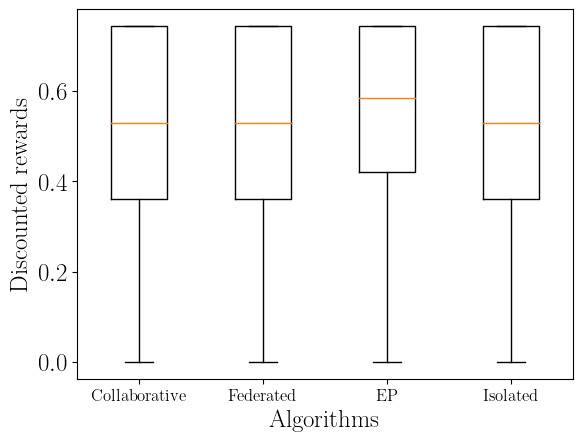

In [9]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Collaborative', 'Federated', 'EP', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

# plt.title("Discounted rewards")
fig.savefig('nasa_boxplot.png')
plt.show()

In [23]:
df_data.describe()

,collab,collab_1,isolated,collab_2,EP
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,1.191918,1.191918,0.971981,1.191918,1.194185
std,1.454517,1.454517,1.062039,1.454517,1.435991
min,0.269503,0.269503,0.269503,0.269503,0.287471
25%,0.514542,0.514542,0.499345,0.514542,0.499345
50%,0.610405,0.610405,0.630104,0.610405,0.667558
75%,0.975056,0.975056,0.990247,0.975056,0.941717
max,5.348952,5.348952,4.956021,5.348952,5.348952


In [24]:
np.mean(collab_cost), np.mean(iso_cost)

(1.1919184609568596, 0.9719807257472146)

In [25]:
np.std(collab_cost), np.std(iso_cost)

(1.4176873363562357, 1.0351476717052108)

In [30]:
N = len(df_data)
std_collab = np.std(collab_cost)
std_iso = np.std(iso_cost)
mu_collab = np.mean(collab_cost)
mu_iso = np.mean(iso_cost)
se = np.sqrt(std_collab**2 / N + std_iso**2 / N)
t_stat = (mu_collab - mu_iso) / se
t_stat

0.5603288145470903

In [31]:
t_crit_val = stats.t.ppf(0.975, 2*N-2)
t_crit_val

2.024394164575136

# Battery

In [4]:
collab_file_name = "experiment_results/4_3_14_0_battery1_collaborative_2025-03-09-21-02-00/result.json"
iso_file_name = "experiment_results/4_3_14_0_battery1_isolated_2025-03-09-21-03-56/result.json"
ep_file_name = "experiment_results/4_3_14_0_battery1_EP_2025-03-09-21-24-38/result.json"
collab_lap_1_file_name = "experiment_results/4_3_14_1.0_battery1_collaborative_2025-03-09-20-45-34/result.json"
collab_lap_2_file_name = "experiment_results/4_3_14_3.0_battery1_collaborative_2025-03-09-20-53-44/result.json"

collab_cost = calc_cost(collab_file_name)
iso_cost = calc_cost(iso_file_name)
ep_cost = calc_cost(ep_file_name)
collab_1_cost = calc_cost(collab_lap_1_file_name)
collab_2_cost = calc_cost(collab_lap_2_file_name)

In [5]:
# sim_accu = [collab_cost[collab_cost < 4], collab_1_cost[collab_1_cost < 4], collab_2_cost[collab_2_cost < 4]
#             , ep_cost[ep_cost < 4], iso_cost[iso_cost < 4]]
sim_accu = [collab_cost, collab_1_cost, collab_2_cost, ep_cost, iso_cost]
# sim_accu_total = [collab_cost_total, collab_1_cost_total, collab_2_cost_total, ep_cost_total, iso_cost_total]
df_data = pd.DataFrame(columns=['collab', 'collab_1', 'collab_2' 'EP', 'isolated'])
df_data['collab'] = collab_cost
df_data['collab_1'] = collab_1_cost
df_data['collab_2'] = collab_2_cost
df_data['isolated'] = iso_cost
df_data['EP'] = ep_cost

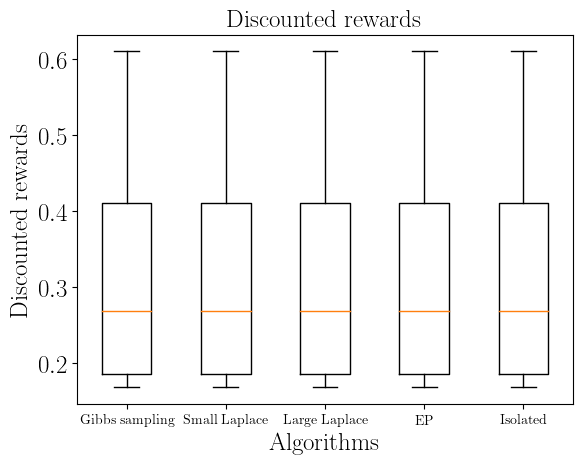

In [6]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Gibbs sampling', 'Small Laplace', 'Large Laplace', 'EP', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.title("Discounted rewards")
plt.show()

In [13]:
with open(collab_file_name, 'r') as f:
    s_collab = json.load(f)
    
with open(ep_file_name, 'r') as f:
    s_ep = json.load(f)
    
with open(collab_lap_1_file_name, 'r') as f:
    s_collab_1 = json.load(f)

for i in range(len(s_collab['hist_cost'])):
    print(s_collab['hist_cost'][i])
    print(s_ep['hist_cost'][i])
    print('-'*20)

[[32, -5.036249016797891], [28, -39.00010388852365], [28, -5.037735964360181]]
[[32, -5.036249016797891], [28, -39.00010388852365], [28, -5.037735964360181]]
--------------------
[[40, -5.033448587928483], [32, -5.036249016797891], [30, -5.036985018669412]]
[[40, -5.033448587928483], [32, -5.036249016797891], [30, -5.036985018669412]]
--------------------
[[27, -5.0381171357173535], [34, -5.035527661363613], [30, -5.036985018669412]]
[[27, -5.0381171357173535], [34, -5.035527661363613], [30, -5.036985018669412]]
--------------------
[[30, -5.036985018669412], [59, -5.027634173858118], [31, -37.990266802930606]]
[[30, -5.036985018669412], [59, -5.027634173858118], [31, -37.990266802930606]]
--------------------


In [10]:
s_collab['mu_mean_hist'][0]

[0.9405047501013587, 0.866752014393006, 0.8176048326128257, 0.5801014241307375]

In [11]:
s_ep['mu_mean_hist'][0]

[3.7951660144000003, 3.72315653006, 3.69953562015, 3.5440585764800003]

In [14]:
s_collab_1['mu_mean_hist'][0]

[0.9176352719487512,
 0.8601628187363695,
 0.8091459937793147,
 0.5845369312334485]